In [1]:
import numpy as np
from meth1_E import Expl_Euler, Expl_Heun, ERK3, ERK4


N_pop = 1000     # total population
beta  = 1.5     # transmission rate
gamma = 0.5     # recovery rate
#basic reproduction number R0 = beta/gamma = 3

def F(t, y):
    S, I, R = y
    dS = -beta * S * I / N_pop
    dI =  beta * S * I / N_pop - gamma * I
    dR =  gamma * I
    return np.array([dS, dI, dR])

T_span = (0, 30)
y0     = np.array([N_pop - 1, 1.0, 0.0])   
# S(0)=N_pop-1, I(0)=1 initial infective, R(0)=0 no one recovered
N      = 60  # number of time steps

t, sol_euler, _ = Expl_Euler(F, T_span, y0, N)
t, sol_heun,  _ = Expl_Heun(F, T_span, y0, N)
t, sol_erk3,  _ = ERK3(F, T_span, y0, N)
t, sol_erk4,  _ = ERK4(F, T_span, y0, N)

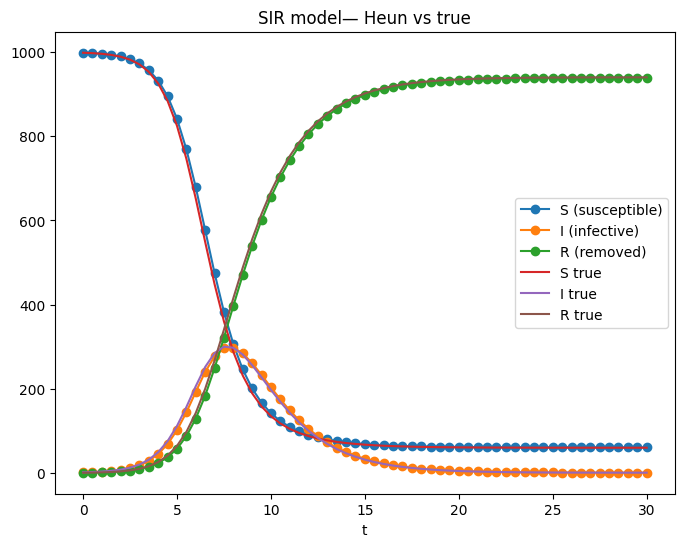

In [2]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

sol_ref = solve_ivp(F, T_span, y0, t_eval=t, rtol=1e-10, atol=1e-12)

plt.figure(figsize=(8, 6))
for i, lab in enumerate(['S (susceptible)', 'I (infective)', 'R (removed)']):
    plt.plot(t, sol_heun[:, i], 'o-',label=lab)
for i, lab in enumerate(['S', 'I', 'R']):
    plt.plot(t,sol_ref.y[i,:],label=lab+' true')
plt.xlabel('t') 
plt.title('SIR model— Heun vs true')
plt.legend()
plt.show()

     N            h    err_euler     err_heun     err_erk3     err_erk4
    64    4.688e-01    2.176e+02    2.503e+01    2.319e+00    2.197e-01
   128    2.344e-01    1.128e+02    7.204e+00    3.453e-01    1.657e-02
   256    1.172e-01    5.728e+01    1.942e+00    4.712e-02    1.134e-03
   512    5.859e-02    2.880e+01    5.050e-01    6.155e-03    7.416e-05
  1024    2.930e-02    1.443e+01    1.288e-01    7.865e-04    4.744e-06
  2048    1.465e-02    7.222e+00    3.253e-02    9.939e-05    3.003e-07


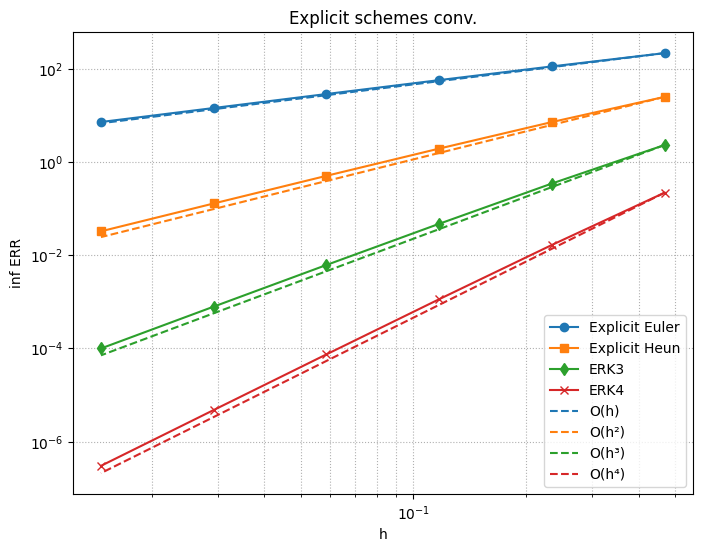

In [3]:
Ns = [2**k for k in range(6, 12)] 

hs = []
errs_e = []
errs_h = []
errs_3 = []
errs_4 = []

for N in Ns:
    t_num, sol_e,  _ = Expl_Euler(F, T_span, y0, N)
    t_num, sol_h,  _ = Expl_Heun(F, T_span, y0, N)
    t_num, sol_3,  _ = ERK3(F, T_span, y0, N)
    t_num, sol_4,  _ = ERK4(F, T_span, y0, N)

    sol_ivp_local = solve_ivp(F, T_span, y0, t_eval=t_num, rtol=1e-12, atol=1e-14)
    y_ref = sol_ivp_local.y.T   
    err_e  = np.max(np.abs(sol_e  - y_ref))
    err_hn = np.max(np.abs(sol_h  - y_ref))
    err_3  = np.max(np.abs(sol_3  - y_ref))
    err_4  = np.max(np.abs(sol_4  - y_ref))

    h = (T_span[1] - T_span[0]) / N
    hs.append(h)
    errs_e.append(err_e)
    errs_h.append(err_hn)
    errs_3.append(err_3)
    errs_4.append(err_4)

print(f"{'N':>6} {'h':>12} {'err_euler':>12} {'err_heun':>12} {'err_erk3':>12} {'err_erk4':>12}")
for N, h, e, hn, r3, r4 in zip(Ns, hs, errs_e, errs_h, errs_3, errs_4):
    print(f"{N:6d} {h:12.3e} {e:12.3e} {hn:12.3e} {r3:12.3e} {r4:12.3e}")

hs     = np.array(hs)
errs_e = np.array(errs_e)
errs_h = np.array(errs_h)
errs_3 = np.array(errs_3)
errs_4 = np.array(errs_4)

plt.figure(figsize=(8, 6))
plt.loglog(hs, errs_e, 'o-', label='Explicit Euler')
plt.loglog(hs, errs_h, 's-', label='Explicit Heun')
plt.loglog(hs, errs_3, 'd-', label='ERK3')
plt.loglog(hs, errs_4, 'x-', label='ERK4')

for p, err0, sty, lab in [(1,errs_e,'--','O(h)'),(2,errs_h,'--','O(h²)'),
                           (3,errs_3,'--','O(h³)'),(4,errs_4,'--','O(h⁴)')]:
    plt.loglog(hs, err0[0] / hs[0]**p * hs**p, sty, color=f'C{p-1}', label=lab)

plt.xlabel('h'); plt.ylabel('inf ERR')
plt.grid(True, which='both', ls=':')
plt.title("Explicit schemes conv.")
plt.legend()
plt.show()